In [1]:
import os
import sys
os.chdir("/home/wz369/rds/hpc-work/PINN_dynamics")

In [7]:
# import cospar as cs
import scanpy as sc
import numpy as np
import pandas as pd

In [8]:
import palantir

In [9]:
sc.set_figure_params(
    figsize=(3,3), dpi=60, frameon=False
)

# data download
Download data from figshare with:

```linux
wget --user-agent="Mozilla/5.0" \
>      --content-disposition \
>      -O weineb_invitro.h5ad \
>     "https://figshare.com/ndownloader/files/41591139"
```

In [5]:
# no full genes names
# no raw
adata_orig = cs.hf.read("data/weineb_invitro.h5ad")
adata_orig.obsm['X_spring'] = adata_orig.obs[['SPRING-x', 'SPRING-y']].values
adata_orig

AnnData object with n_obs × n_vars = 130887 × 2447
    obs: 'Library', 'Cell barcode', 'Time point', 'Starting population', 'Cell type annotation', 'Well', 'SPRING-x', 'SPRING-y', 'clone_idx', 'fate_observed', 't0_fated', 'train', 'test'
    uns: 'Cell type annotation_colors', 'neighbors', 'train_colors', 'umap'
    obsm: 'X_pca', 'X_spring', 'X_umap', 'X_umap_old'
    layers: 'X_scaled'
    obsp: 'connectivities', 'distances'

In [34]:
# raw, without processing
adata = sc.read_h5ad("data/Complete_LARRY_dataset_adata_preprocessed.h5ad")
adata

AnnData object with n_obs × n_vars = 130887 × 25289
    obs: 'n_counts', 'Time_Point', 'Source', 'Well', 'mito_frac', 'time_info', 'state_info', 'precomputed_fate_bias', 'selected_clonal_cells', 'Gata1_states'
    var: 'highly_variable'
    uns: 'clonal_time_points', 'data_des', 'max_mito', 'min_tot', 'neighbors', 'state_info_colors', 'time_info_colors', 'time_ordering', 'umap'
    obsm: 'X_clone', 'X_emb', 'X_pca', 'X_umap'

In [53]:
adata.X[:5, :5].A

array([[0.       , 1.2599825, 0.       , 0.       , 0.       ],
       [0.       , 0.       , 1.0776678, 0.       , 0.       ],
       [0.       , 0.       , 1.6736541, 0.       , 0.       ],
       [0.       , 0.       , 0.       , 0.       , 0.       ],
       [0.       , 0.       , 5.6705947, 0.       , 0.       ]],
      dtype=float32)

In [52]:
adata.obs_names[:10], adata.var_names[:10]

(Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype='object', name='index'),
 Index(['0610006L08Rik', '0610007P14Rik', '0610009B22Rik', '0610009E02Rik',
        '0610009L18Rik', '0610009O20Rik', '0610010F05Rik', '0610010K14Rik',
        '0610011F06Rik', '0610012D04Rik'],
       dtype='object', name='index'))

In [39]:
np.all(adata.obs['Cell type annotation'] == adata_orig.obs['Cell type annotation'])

True

In [ ]:
# transfer labels
for obs_key  in adata_orig.obs_keys():
    if obs_key not in  adata.obs_keys():
        adata.obs[obs_key] = adata_orig[adata.obs_names].obs[obs_key].copy()
        
for obsm_key  in adata_orig.obsm_keys():
    if obsm_key not in  adata.obsm_keys():
        adata.obsm[obsm_key] = adata_orig[adata.obs_names].obsm[obsm_key].copy()

        
for obsp_key  in adata_orig.obsp.keys():
    if obsp_key not in  adata.obsp.keys():
        adata.obsp[obsp_key] = adata_orig[adata.obs_names].obsp[obsp_key].copy()

In [57]:
adata.obsm['X_umap_old'] = adata.obsm['X_umap'].copy()
sc.pp.neighbors(adata, n_neighbors=30)
sc.tl.umap(adata)

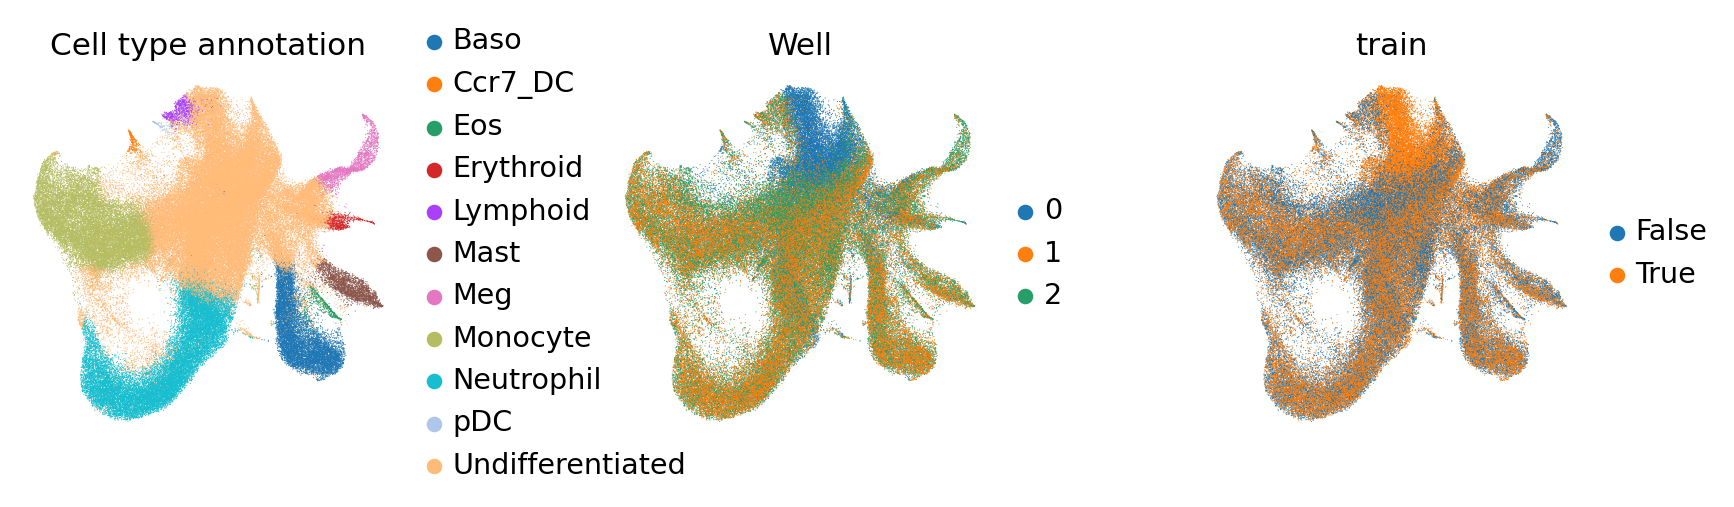

In [58]:
sc.pl.umap(adata, color=['Cell type annotation', 'Well', 'train'], wspace=0.4)

In [54]:
adata.write_h5ad("data/Complete_LARRY_dataset_adata_preprocessed.h5ad")

## clean cell states

In [59]:
sc.tl.leiden(adata)

/tmp/ipykernel_158337/3467744858.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out


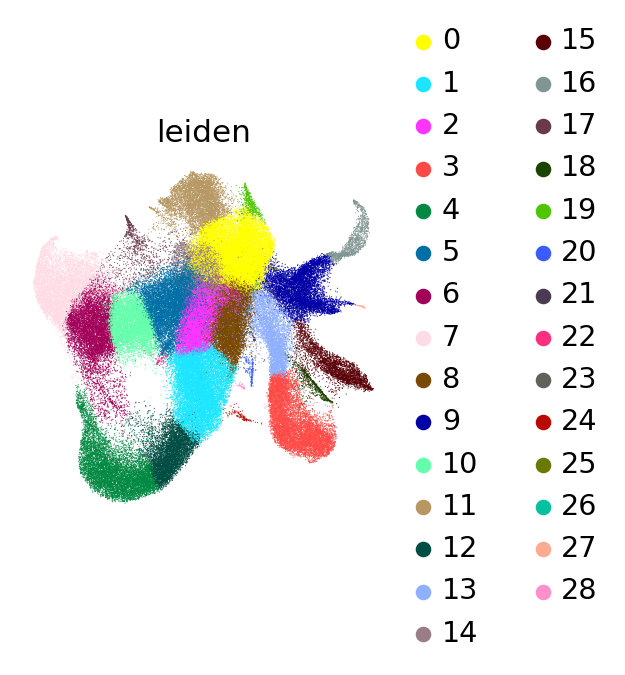

In [60]:
sc.pl.umap(adata, color='leiden')

In [70]:
unwanted_clusters = ['17', '20', '24' ,'22', '20', '28']
clean_ad = adata[~adata.obs.leiden.isin(unwanted_clusters)].copy()
clean_ad

AnnData object with n_obs × n_vars = 129199 × 25289
    obs: 'n_counts', 'Time_Point', 'Source', 'Well', 'mito_frac', 'time_info', 'state_info', 'precomputed_fate_bias', 'selected_clonal_cells', 'Gata1_states', 'Cell type annotation', 'Library', 'Cell barcode', 'Time point', 'Starting population', 'SPRING-x', 'SPRING-y', 'clone_idx', 'fate_observed', 't0_fated', 'train', 'test', 'leiden'
    var: 'highly_variable'
    uns: 'clonal_time_points', 'data_des', 'max_mito', 'min_tot', 'neighbors', 'state_info_colors', 'time_info_colors', 'time_ordering', 'umap', 'Well_colors', 'Cell type annotation_colors', 'DM_EigenValues', 'train_colors', 'leiden', 'leiden_colors'
    obsm: 'X_clone', 'X_emb', 'X_pca', 'X_umap', 'X_spring', 'X_umap_old', 'DM_EigenVectors'
    obsp: 'connectivities', 'distances', 'DM_Kernel', 'DM_Similarity'

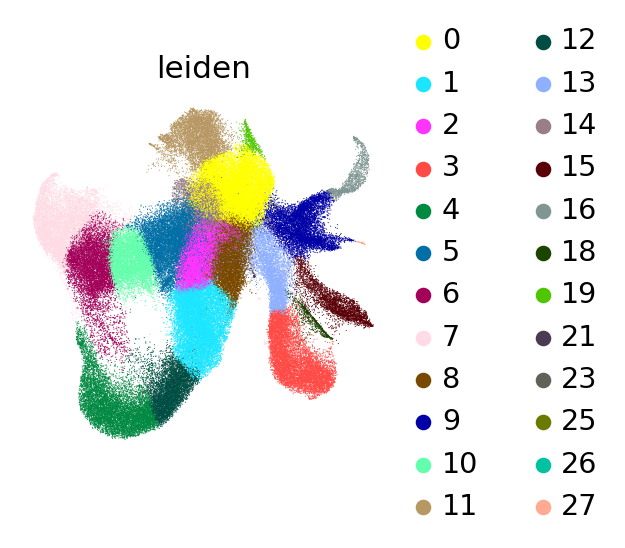

In [71]:
sc.pl.umap(clean_ad, color=['leiden'],)

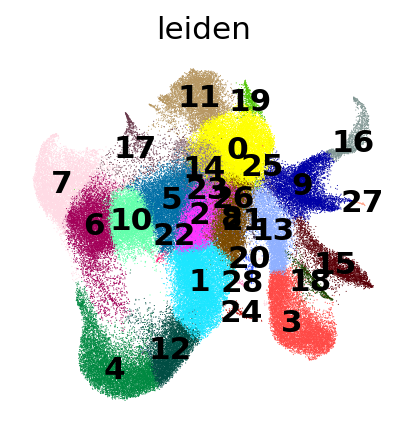

In [72]:
sc.pl.umap(adata, color=['leiden'], legend_loc='on data')

# identify root cell using HSCscore

## HSCscore with scanpy function

In [86]:
geneset_df = pd.read_csv("data/mouse_geneset/Rodriguez-Fraticelli_HSC_gene_signatures.csv", skiprows=1)
# geneset_df = np.genfromtxt("data/mouse_geneset/model_molo_genes.txt", dtype='str')
geneset_df

,Low-output_Rodriguez_et_al,High-output_Rodriguez_et_al,Multilineage_Rodriguez_et_al,Mk-bias_Rodriguez_et_al,Serial-engraftment_Rodriguez_et_al,Stemscore_Giladi_et_al,RACFP_DIM_Lauridsen_et_al,SuMO_Wilson_et_al,MolO_Wilson_et_al,HSC_vs_MPP4_Cabezas-Wallscheid_et_al,...,HSC4 cluster,dHSC_aHSC_single-cell_Cabezas-Wallscheid_et_al,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24
0,Mpl,Plac8,Plac8,Ifitm3,Ifitm1,1110017F19Rik,Ltb,Ly6a,Procr,Prss41,...,Jun,ENSMUSG00000064339,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ifitm3,H2afy,H2afy,Rbms3,Tsc22d1,2410006H16Rik;Snord65,Lst1,Ifitm1,Pdzk1ip1,Sh3gl3,...,Egr1,ENSMUSG00000098178,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Ifitm1,Cdk6,Mpo,Ifitm1,Mycn,2900062L11Rik;6530401D17Rik,Ypel3,Inhba,Ltb,Ncam2,...,Ier2,CYTB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Tgm2,Cd34,Elane,Adgrg1,Vwf,4931406C07Rik,Ly6a,Mllt3,Mllt3,Sh3rf3,...,Plac8,Serpinb1a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,H2-K1,Nkg7,Ybx1,Tsc22d1,Glul,AK046388,Ctsf,Wfdc2,Ifitm1,Ak7,...,Ptma,Actb,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3841,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3842,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3843,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3844,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [87]:
# wilson molo is the HSCscore
# molo_geneset = geneset_df['MolO_Wilson_et_al'].dropna().tolist()
molo_geneset = np.genfromtxt("data/mouse_geneset/model_molo_genes.txt", dtype='str')
inte_genes = np.intersect1d(molo_geneset, adata.var_names)
print(f'# molo genes {len(molo_geneset)}, # overlap genes {len(inte_genes)}')

sumo_geneset = geneset_df['SuMO_Wilson_et_al'].dropna().tolist()
sumo_genes = np.intersect1d(sumo_genes, adata.var_names)
print(f'# molo genes {len(sumo_geneset)}, # overlap genes {len(sumo_genes)}')

# molo genes 103, # overlap genes 102
# molo genes 21, # overlap genes 102


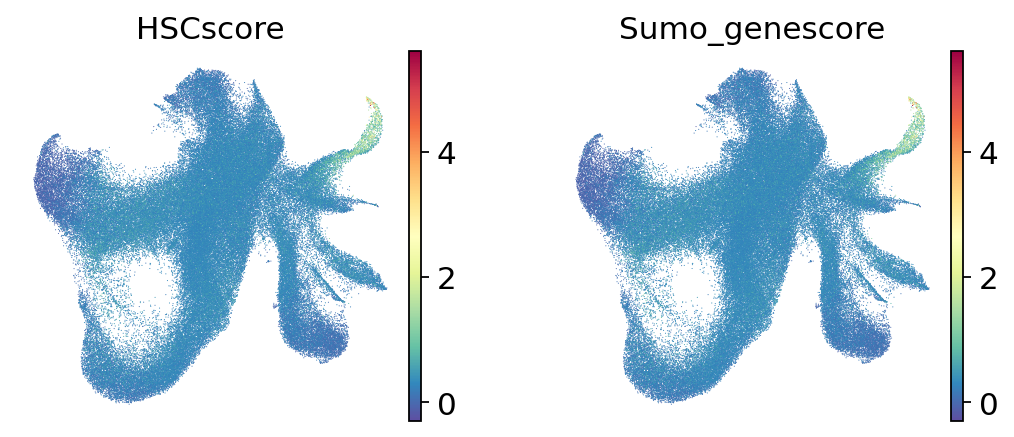

In [88]:
sc.tl.score_genes(clean_ad, gene_list=inte_genes, score_name='HSCscore')
sc.tl.score_genes(clean_ad, gene_list=sumo_genes, score_name='Sumo_genescore')
sc.pl.umap(clean_ad, color=['HSCscore','Sumo_genescore'])

In [101]:
len(molo_geneset)

103

In [103]:
molo_X.shape

(130887, 102)

In [105]:
inte_genes.shape

(102,)

## Predict HSC score with ML regressor、

Scanpy function `score_genes()` seems malfunction. We use Fiona's method:

https://nbviewer.org/github/fionahamey/hscScore/blob/master/hscScore_demonstration_notebook.ipynb

In [111]:
molo_X = adata[:,inte_genes].X.A
molo_df = pd.DataFrame(molo_X, columns=inte_genes)

In [112]:
[g for g in molo_geneset if g not in inte_genes]

['Mki67']

In [117]:
molo_df['Mki67'] = np.zeros((130887,))
molo_df[molo_geneset].to_csv("data/molo_lognrom.csv")

```python
#! /rds/user/wz369/hpc-work/LIBS/mamba/envs/jupyter/bin/python
>>> import os
>>> import sys
>>> os.chdir("/home/wz369/rds/hpc-work/PINN_dynamics")
>>> import pickle
>>> import sklearn
>>> hsc_score = pickle.load(open('data/mouse_geneset/hscScore_model.pkl', 'rb'))
>>> molo_x = pd.read_csv("data/molo_lognrom.csv",index_col=0)
>>> redicted_hsc_scores = hsc_score.predict(molo_x.values)
>>> pd.DataFrame(redicted_hsc_scores, columns=['HSCscore']).to_csv("data/Weirenb_HSCscore.csv")
>>> 

```

## load results

In [118]:
adata.obs['HSCscore'] = pd.read_csv("data/Weirenb_HSCscore.csv")['HSCscore'].values

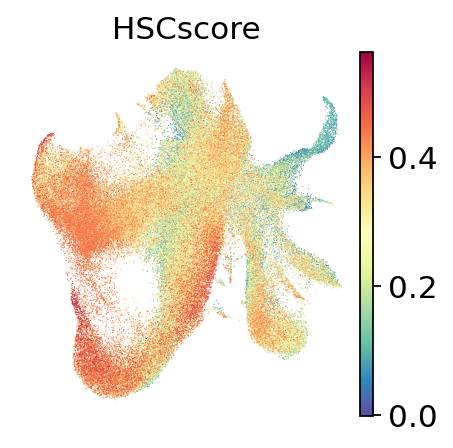

In [121]:
sc.pl.umap(adata, color=['HSCscore'])

In [122]:
clean_ad.obs['HSCscore'] = adata[clean_ad.obs_names].obs['HSCscore']

In [123]:
clean_ad.write_h5ad("data/Weinreb_13k_clean.h5ad")

In [125]:
adata.write_h5ad("data/Complete_LARRY_dataset_adata_preprocessed.h5ad")

# try integration

In [77]:
sc.external.pp.harmony_integrate(clean_ad, key = 'Library', basis='X_pca')

2025-10-30 08:52:04,140 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-10-30 08:52:37,986 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-10-30 08:52:38,739 - harmonypy - INFO - Iteration 1 of 10
2025-10-30 08:53:48,189 - harmonypy - INFO - Iteration 2 of 10
2025-10-30 08:54:54,452 - harmonypy - INFO - Iteration 3 of 10
2025-10-30 08:56:04,764 - harmonypy - INFO - Iteration 4 of 10
2025-10-30 08:57:14,248 - harmonypy - INFO - Iteration 5 of 10
2025-10-30 08:58:24,246 - harmonypy - INFO - Iteration 6 of 10
2025-10-30 08:59:33,682 - harmonypy - INFO - Converged after 6 iterations


In [83]:
sc.external.pp.harmony_integrate(clean_ad, key = 'Well', basis='X_pca', adjusted_basis = 'X_pca_harmony_well')

2025-10-30 09:10:03,058 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-10-30 09:10:39,895 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-10-30 09:10:40,642 - harmonypy - INFO - Iteration 1 of 10
2025-10-30 09:11:39,756 - harmonypy - INFO - Iteration 2 of 10
2025-10-30 09:12:39,942 - harmonypy - INFO - Iteration 3 of 10
2025-10-30 09:13:39,238 - harmonypy - INFO - Converged after 3 iterations


In [86]:
sc.pp.neighbors(clean_ad, n_neighbors = 35, use_rep='X_pca_harmony_well')
sc.tl.umap(clean_ad, init_pos=clean_ad.obsm['X_umap_old'])

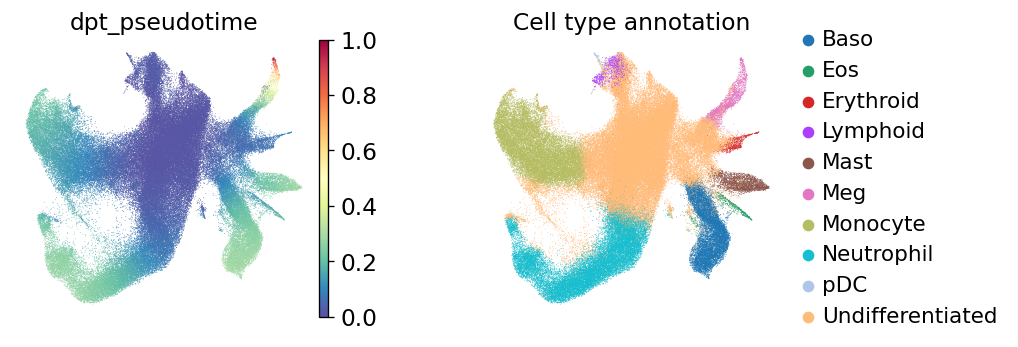

In [87]:
sc.pl.umap(clean_ad, color=['dpt_pseudotime', 'Cell type annotation'], wspace=0.4)

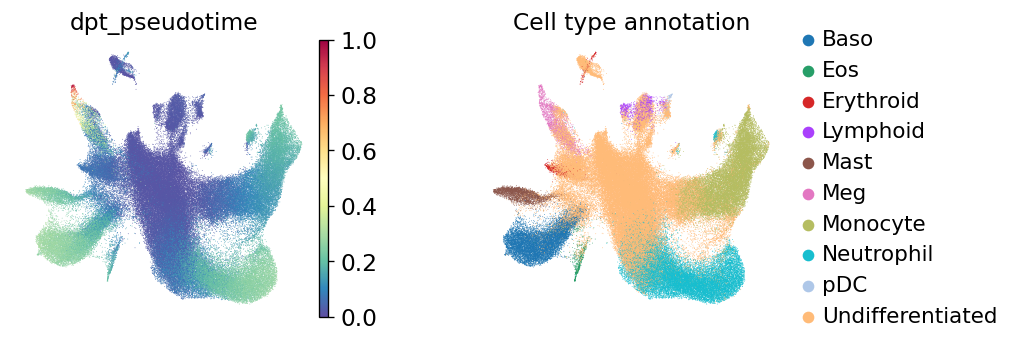

In [82]:
clean_ad.obsm['X_umap_harmony'] = clean_ad.obsm['X_umap']
sc.pl.umap(clean_ad, color=['dpt_pseudotime', 'Cell type annotation'], wspace=0.4)

In [ ]:
clean_ad.write_h5ad("data/Weinreb_13k_clean.h5ad")

# run palantir

In [5]:
clean_ad = sc.read_h5ad("data/Weinreb_13k_clean.h5ad")
clean_ad

AnnData object with n_obs × n_vars = 129199 × 25289
    obs: 'n_counts', 'Time_Point', 'Source', 'Well', 'mito_frac', 'time_info', 'state_info', 'precomputed_fate_bias', 'selected_clonal_cells', 'Gata1_states', 'Cell type annotation', 'Library', 'Cell barcode', 'Time point', 'Starting population', 'SPRING-x', 'SPRING-y', 'clone_idx', 'fate_observed', 't0_fated', 'train', 'test', 'leiden', 'HSCscore', 'Sumo_genescore', 'palantir_pseudotime', 'palantir_entropy'
    var: 'highly_variable'
    uns: 'Cell type annotation_colors', 'DM_EigenValues', 'Well_colors', 'clonal_time_points', 'data_des', 'leiden', 'leiden_colors', 'max_mito', 'min_tot', 'neighbors', 'palantir_waypoints', 'state_info_colors', 'time_info_colors', 'time_ordering', 'train_colors', 'umap'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_clone', 'X_emb', 'X_pca', 'X_spring', 'X_umap', 'X_umap_old', 'palantir_fate_probabilities'
    obsp: 'DM_Kernel', 'DM_Similarity', 'connectivities', 'distances'

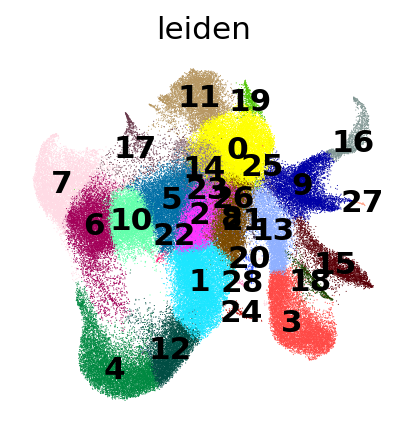

In [72]:
sc.pl.umap(adata, color=['leiden'], legend_loc='on data')

In [ ]:
sc.pl.umap(clean_ad, o)

In [36]:
clean_ad.uns['iroot'] = 43583

In [103]:
sc.tl.diffmap(clean_ad, n_comps=5)
sc.tl.dpt(clean_ad, n_dcs=5)

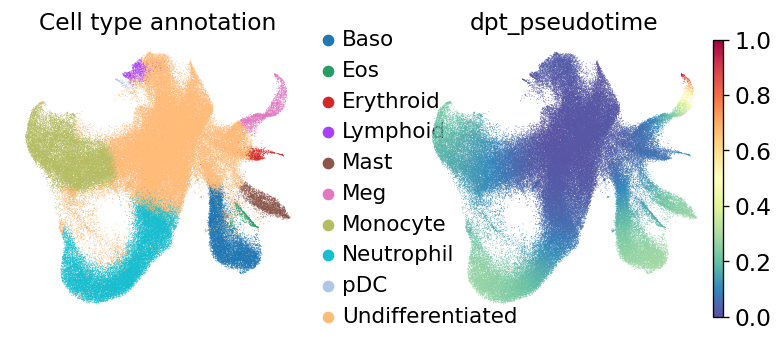

In [104]:
sc.pl.umap(clean_ad, color=['Cell type annotation', 'dpt_pseudotime'])

In [98]:
max_pdt = clean_ad.obs.groupby("Cell type annotation").agg(
    {"dpt_pseudotime": [max, 'idxmax']}
)
max_pdt = max_pdt.drop(["Undifferentiated"]) #, 'Monocyte', 'Neutrophil'])
max_pdt

dpt_pseudotime        
                                max  idxmax
Cell type annotation                       
Baso                       0.323659   36716
Eos                        0.313319  112004
Erythroid                  0.132611   36991
Lymphoid                   0.036465   87530
Mast                       0.308510  111123
Meg                        1.000000   40797
Monocyte                   0.237113   84429
Neutrophil                 0.304546   33839
pDC                        0.042909  127443

In [56]:
clean_ad.obs.groupby("leiden").agg(
    {"dpt_pseudotime": [max, 'idxmax']}
)

dpt_pseudotime        
                  max  idxmax
leiden                       
0            0.078755   93816
1            0.123173   68333
2            0.072390   77624
3            0.323659   36716
4            0.304546   33839
5            0.123665    6256
6            0.211365    2114
7            0.240231    2409
8            0.068727   88097
9            0.177647  118306
10           0.117527  101029
11           0.130701  123292
12           0.220640    3609
13           0.169021  120649
14           0.083596   38157
15           0.308510  111123
16           1.000000   40797
18           0.269047   34607
19           0.149022   34390
21           0.215979   34530
23           0.208628   36264
25           0.063491  128450
26           0.030536   20632
27           0.131972   15887

In [99]:
terminal = max_pdt[('dpt_pseudotime', 'idxmax')]
# make obs name as index
terminal_states = pd.Series(
    terminal.index,
    index=terminal.values)
# terminal_states['2409'] = 'Monocyte'
# terminal_states['33839'] = 'Neutrophil'

terminal_states

36716           Baso
112004           Eos
36991      Erythroid
87530       Lymphoid
111123          Mast
40797            Meg
84429       Monocyte
33839     Neutrophil
127443           pDC
Name: Cell type annotation, dtype: category
Categories (10, object): ['Baso', 'Eos', 'Erythroid', 'Lymphoid', ..., 'Monocyte', 'Neutrophil', 'pDC', 'Undifferentiated']

resume

In [91]:
# Run diffusion maps
dm_res = palantir.utils.run_diffusion_maps(clean_ad, pca_key='X_pca_harmony_well', knn=15)
ms_data = palantir.utils.determine_multiscale_space(clean_ad)

In [92]:
dm_res['EigenVectors'].shape

(129199, 10)

In [93]:
ms_data.shape

(129199, 6)

In [70]:
early_cell = clean_ad[
    clean_ad.obs.query("`leiden` == '19' & `Time_Point` == '2.0'").index
    ]

idx_max = early_cell.obs['HSCscore'].idxmax()
print(early_cell.obs['HSCscore'].max(), idx_max)

0.4902298634530836 44042


In [89]:
early_cell.obs['HSCscore'].nlargest(10)

index
44042    0.490230
57577    0.483826
51987    0.471892
43779    0.468377
56284    0.468031
59535    0.465621
53665    0.465179
49278    0.462920
58552    0.460848
53091    0.460072
Name: HSCscore, dtype: float64

(<Figure size 360x360 with 1 Axes>, <Axes: >)

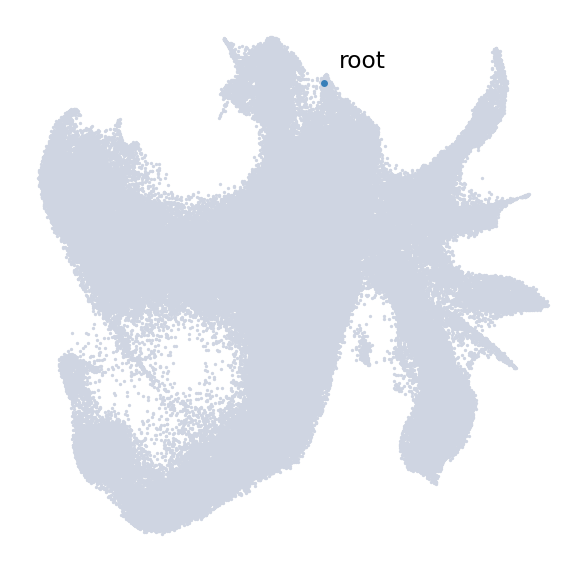

In [100]:
palantir.plot.highlight_cells_on_umap(
    clean_ad, pd.Series(
    ["root"],
    index=['44042'],
))

(<Figure size 360x360 with 1 Axes>, <Axes: >)

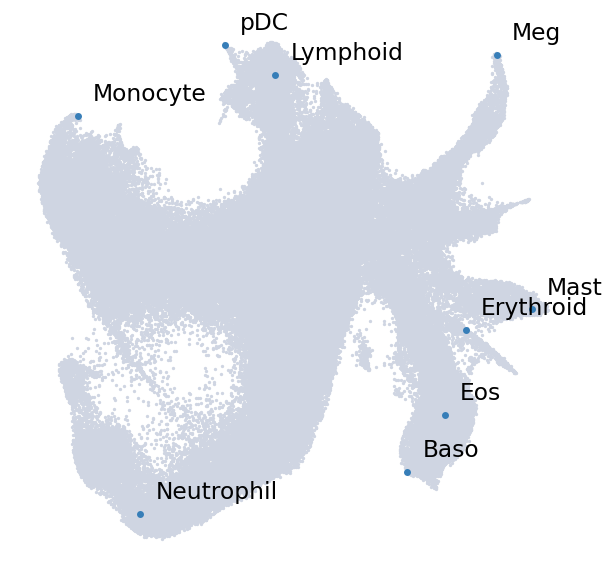

In [101]:
palantir.plot.highlight_cells_on_umap(clean_ad,terminal_states)

In [91]:
np.where(clean_ad.obs_names == '44042')

(array([43583]),)

In [102]:
# run palantir
pr_res = palantir.core.run_palantir(
    clean_ad, early_cell = '44042',  num_waypoints=1000,  #terminal_states = terminal_states,
)

Sampling and flocking waypoints...
Time for determining waypoints: 0.4291464487711589 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 5.496776203314464 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9997
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


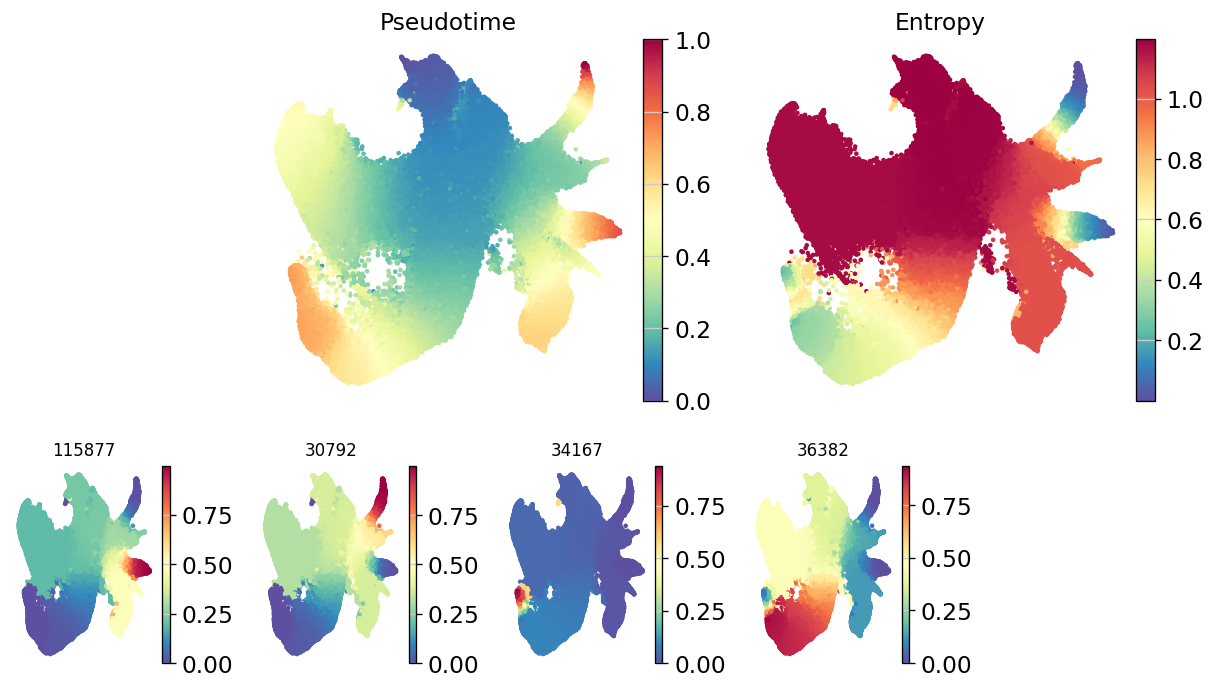

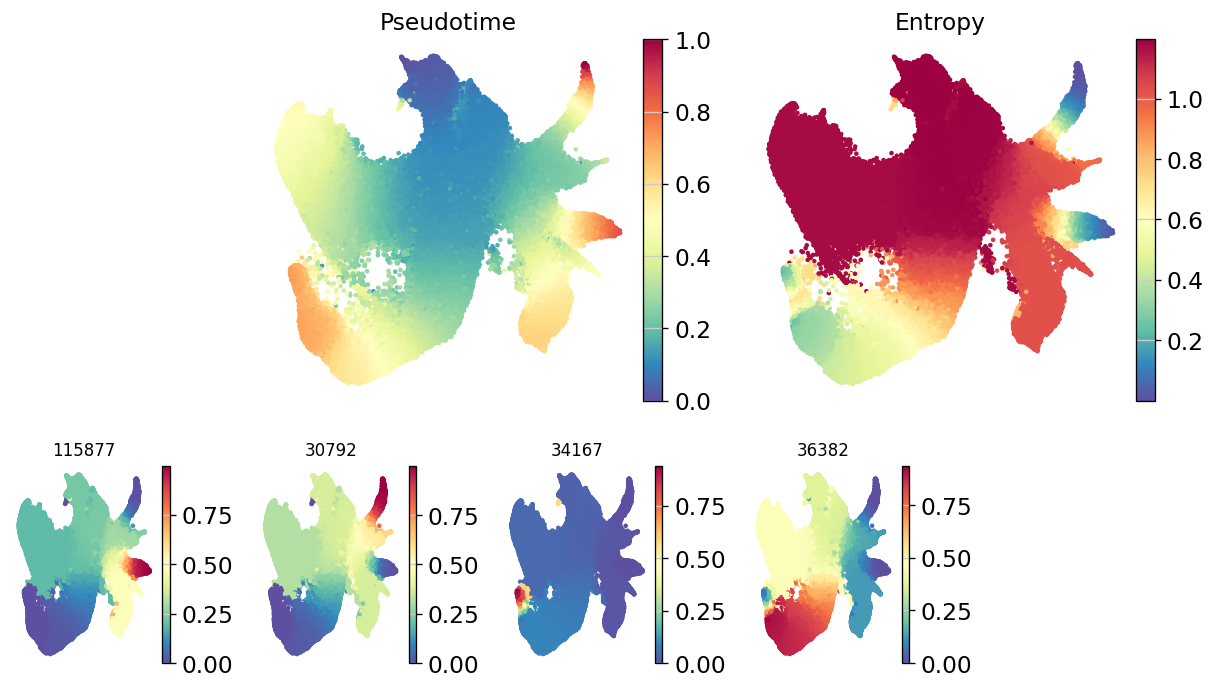

In [103]:
palantir.plot.plot_palantir_results(clean_ad, s=3)

In [96]:
from sklearn import preprocessing

In [97]:
scaler = preprocessing.StandardScaler()

In [106]:
clean_ad.obsm['DM_scaled'] = scaler.fit_transform(clean_ad.obsm['X_diffmap'])

In [107]:
clean_ad.obsm['DM_scaled'].std(axis=0)

array([1.        , 0.99999994, 1.        , 1.        , 0.99999994],
      dtype=float32)

In [88]:
clean_ad.write_h5ad("data/Weinreb_13k_clean.h5ad")

# sampled Delta DM scaled

In [11]:
%load_ext autoreload
%autoreload 2

In [12]:
import PINN

In [10]:
clean_ad = sc.read_h5ad("data/Weinreb_13k_clean.h5ad")
clean_ad

AnnData object with n_obs × n_vars = 129199 × 25289
    obs: 'n_counts', 'Time_Point', 'Source', 'Well', 'mito_frac', 'time_info', 'state_info', 'precomputed_fate_bias', 'selected_clonal_cells', 'Gata1_states', 'Cell type annotation', 'Library', 'Cell barcode', 'Time point', 'Starting population', 'SPRING-x', 'SPRING-y', 'clone_idx', 'fate_observed', 't0_fated', 'train', 'test', 'leiden', 'HSCscore', 'Sumo_genescore', 'palantir_pseudotime', 'palantir_entropy', 'dpt_pseudotime'
    var: 'highly_variable'
    uns: 'Cell type annotation_colors', 'DM_EigenValues', 'Well_colors', 'clonal_time_points', 'data_des', 'diffmap_evals', 'iroot', 'leiden', 'leiden_colors', 'max_mito', 'min_tot', 'neighbors', 'palantir_waypoints', 'state_info_colors', 'time_info_colors', 'time_ordering', 'train_colors', 'umap'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'DM_scaled', 'X_clone', 'X_diffmap', 'X_emb', 'X_pca', 'X_spring', 'X_umap', 'X_umap_old', 'palantir_fate_probabilities'
    obsp: '

In [ ]:
clean_ad

In [30]:
clean_ad.obsm['delta_DM_scaled'] = np.stack(delta_X).mean(axis=1)

In [31]:
clean_ad.write_h5ad("data/Weinreb_13k_clean.h5ad")

In [33]:
import cellrank as cr

[autoreload of jinja2.nodes failed: Traceback (most recent call last):
  File "/rds/user/wz369/hpc-work/LIBS/mamba/envs/PINN_env/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/rds/user/wz369/hpc-work/LIBS/mamba/envs/PINN_env/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 500, in superreload
    update_generic(old_obj, new_obj)
  File "/rds/user/wz369/hpc-work/LIBS/mamba/envs/PINN_env/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 397, in update_generic
    update(a, b)
  File "/rds/user/wz369/hpc-work/LIBS/mamba/envs/PINN_env/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 365, in update_class
    update_instances(old, new)
  File "/rds/user/wz369/hpc-work/LIBS/mamba/envs/PINN_env/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 323, in update_instances
    object.__setattr__(ref, "__class__", new)
TypeError: can't app

In [ ]:
import scvelo as scv

In [38]:
std2 = np.std([24000, 30000, 36000])
std4 = np.std([120000, 150000, 180000])
std6 = np.std([300000, 450000, 750000])

clean_ad.uns['pop']  = {
    "mean" : np.array([24000, 30000, 36000]),
    "var" : np.array([int(std2), int(std4), int(std6)]),
    "t" : np.array([2,4,6]),
    "n_lib": np.array([3,3,3])
}

# DM

In [112]:
delta_X, neighbor_ls = PINN.tl.sample_deltax_from_knn(clean_ad,
    max_degree=1,
    k=10,
    n_repeat=3,                                     
    xkey="DM_EigenVectors_multiscaled",
    pseudotimekey='palantir_pseudotime',
    progressbar=True,
    temperature=1)

100%|████████████████████████████████████████████████████████████████████████████████████████████| 129199/129199 [01:35<00:00, 1354.21it/s]


In [113]:
clean_ad.obsm['delta_DM_scaled'] = np.stack(delta_X).mean(axis=1)

In [114]:
cellstate_ad = PINN.tl.make_coord_adata(clean_ad, cellstate_key='DM_EigenVectors_multiscaled', n_dimension=None)
cellstate_ad.layers['delta_DM_scaled'] = cellstate_ad.obsm['delta_DM_scaled']
vk = cr.kernels.VelocityKernel(cellstate_ad, vkey='delta_DM_scaled', xkey='cellstate')

  0%|          | 0/129199 [00:00<?, ?cell/s]

  0%|          | 0/129199 [00:00<?, ?cell/s]

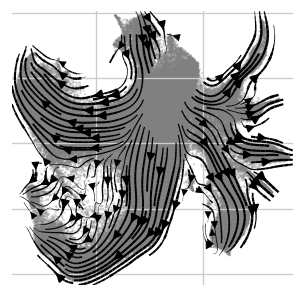

In [115]:
vk.compute_transition_matrix()
vk.plot_projection()

In [116]:
delta_X, neighbor_ls = PINN.tl.sample_deltax_from_knn(clean_ad,
    max_degree=1,
    k=10,
    n_repeat=3,                                     
    xkey="X_pca_harmony_well",
    pseudotimekey='palantir_pseudotime',
    progressbar=True,
    temperature=1)

100%|████████████████████████████████████████████████████████████████████████████████████████████| 129199/129199 [01:35<00:00, 1359.70it/s]


In [118]:
clean_ad.obsm['delta_pca_hw'] = np.stack(delta_X).mean(axis=1)

In [119]:
cellstate_ad = PINN.tl.make_coord_adata(clean_ad, cellstate_key='X_pca_harmony_well', n_dimension=None)
cellstate_ad.layers['delta_pca_hw'] = cellstate_ad.obsm['delta_pca_hw']
vk = cr.kernels.VelocityKernel(cellstate_ad, vkey='delta_pca_hw', xkey='cellstate')

  0%|          | 0/129199 [00:00<?, ?cell/s]

  0%|          | 0/129199 [00:00<?, ?cell/s]

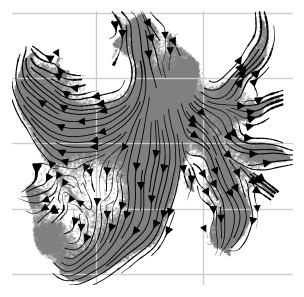

In [120]:
vk.compute_transition_matrix()
vk.plot_projection()